# TITULO

## 1. Introduccion

### 1.1 Contexto

### 1.2 Objetivo

## 2. Carga e Inspeccion Inicial

### 2.1 Importacion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
from IPython.display import display

### 2.2 Carga del Dataset

In [2]:
# Cargamos un diccionario con las traducciones de los codigos de preguntas
with open("data/traducciones.json", "r") as file:
    traducciones = json.load(file)
    traducciones_df = pd.DataFrame(traducciones.items())

# Cargamos el dataset con los datos
df = pd.read_csv("data/EMSE_DatosAbiertos.csv")

### 2.3 Informacion General

In [3]:
df.shape

(56981, 309)

In [4]:
df.isna().sum()

sitio              0
record             0
q1               108
texto_q1         108
q2               536
                ... 
qnpe5g          1949
texto_qnpe5g       0
weight             0
stratum            0
psu                0
Length: 309, dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56981 entries, 0 to 56980
Columns: 309 entries, sitio to psu
dtypes: float64(154), int64(3), object(152)
memory usage: 134.3+ MB


Observamos que el dataset cuenta con 56981 filas y 309 columnas o features.

In [6]:
df.head()

,sitio,record,q1,texto_q1,q2,texto_q2,q3,texto_q3,q4,q5,...,texto_qnpa5g,qnpa7g,texto_qnpa7g,qnpe3g,texto_qnpe3g,qnpe5g,texto_qnpe5g,weight,stratum,psu
0,AG,1,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,1.0,Si,2.0,No,2.0,No,457.09,201801010,19
1,AG,2,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,Si,2.0,No,2.0,No,2.0,No,457.09,201801010,19
2,AG,3,4.0,14 años,1.0,Masculino,4.0,2do año/11vo grado nivel Polimodal o 4to año n...,1.67,56.0,...,Si,2.0,No,2.0,No,2.0,No,261.44,201801010,19
3,AG,4,6.0,16 años,1.0,Masculino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,1.73,70.0,...,No,2.0,No,1.0,Si,1.0,Si,550.90,201801010,19
4,AG,5,3.0,13 años,2.0,Femenino,2.0,9no grado nivel Primario/Polimodal o 2do año n...,NaN,NaN,...,No,2.0,No,2.0,No,2.0,No,457.09,201801010,19


## 3. Comprension de Variables

Se puede observar que el dataset cuenta con 2 columnas para cada pregunta del cuestionario, una numerica y una codificada en texto. Todas las respuestas a las preguntas son de tipo **categorica** y tienen asociado su correspondiente lista de codigos validos presentes en la documentacion.

In [7]:
# Obtenemos todas las columnas que comiencen con "q", 
# aquellas que representan un pregunta del cuestionario.
# Evitamos las columnas que representan la misma pregunta pero con
# su respuesta en formato textual.
df[df.columns[pd.Series(df.columns).str.startswith('q')]].columns

Index(['q1', 'q2', 'q3', 'q4', 'q5', 'q6', 'q10', 'q15', 'q16', 'q17',
       ...
       'qnff2g', 'qnff3g', 'qntob2g', 'qnnotb2g', 'qnbcanyg', 'qnc1g',
       'qnpa5g', 'qnpa7g', 'qnpe3g', 'qnpe5g'],
      dtype='object', length=153)

Observamos entonces que el cuestionario cuenta con 153 preguntas.

## 4. Preseleccion de Variables

Para simplificar el analisis vamos a hacer una preseleccion de las variables que consideramos, a grandes razgos, que podrian estar relacionadas al objetivo final.

In [8]:
from matplotlib.ticker import PercentFormatter
from textwrap import fill

def get_colors(n):
    return plt.cm.tab20(np.arange(n))

def print_question(q, figsize=(12, 5)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    fig.suptitle(f"{q}: {traducciones.get(q, q)}")

    series = df[q]
    labels = df[[q, "texto_" + q]].drop_duplicates().sort_values(by=q)["texto_" + q].dropna()
    labels = [fill(label, width=24) for label in labels]

    # --- Plot 1: Value frequencies as percentages ---
    value_pct = (
        series.value_counts(dropna=True, normalize=True)
        .sort_index()
        .mul(100)
    )
    
    colors = get_colors(len(value_pct))
    max_pct = value_pct.max()

    value_pct.plot(kind="bar", ax=ax1, color=colors)
    ax1.set_title("Distribucion de Respuestas")
    ax1.set_ylabel("Frecuencia (%)")
    ax1.set_xlabel("Respuesta")
    ax1.set_ylim(0, max(100, max_pct * 1.15))
    ax1.yaxis.set_major_formatter(PercentFormatter())
    ax1.set_xticklabels(
        labels[:len(value_pct)],
        rotation=45,
        ha="right"
    )

    # Add labels on bars
    for container in ax1.containers:
        ax1.bar_label(container, fmt="%.1f%%")

    # --- Plot 2: NaN vs Non-NaN percentages ---
    nan_pct = series.isna().mean() * 100
    non_nan_pct = 100 - nan_pct
    max_pct = max(nan_pct, non_nan_pct)

    ax2.barh(
        ["No nulos", "Nulos"],
        [non_nan_pct, nan_pct],
        color=colors
    )
    ax2.set_title("Respuestas Nulas")
    ax2.set_xlabel("Frecuencia (%)")
    ax2.xaxis.set_major_formatter(PercentFormatter())
    ax2.set_xlim(0, max(100, max_pct * 1.15))

    # Add labels on bars
    for container in ax2.containers:
        ax2.bar_label(container, fmt="%.1f%%")

    plt.tight_layout()
    plt.show()

### 4.1 Definicion del Target

Como objetivo de este trabajo se propone preparar los datos para poder predecir si un estudiante se encuentra **en riesgo** de cometer suicidio o no.
Para ello, definimos a la variable target como una derivacion de las features **q25** y **q26**.

In [9]:
print("q25:", traducciones["q25"])

display(df[["q25", "texto_q25"]].sort_values(by="q25").drop_duplicates())

print("q26:", traducciones["q26"])
display(df[["q26", "texto_q26"]].sort_values(by="q26").drop_duplicates())

q25: Durante los últimos 12 meses, ¿hiciste algún plan de cómo intentarías suicidarte?


,q25,texto_q25
18392,1.0,Si
38774,2.0,No
184,NaN,Dato perdido


q26: Durante los últimos 12 meses, ¿cuántas veces intentaste realmente suicidarte?


,q26,texto_q26
0,1.0,0 veces
27900,2.0,1 vez
2247,3.0,2 o 3 veces
670,4.0,4 o 5 veces
52410,5.0,6 o más veces
86,NaN,Dato perdido


Como se puede ver, ambas features son categoricas. En el caso de *q25*, se trata de una categorica binaria, mientras que *q26* se trata de una categorica ordinal.

Para la definicion de nuestra variable target diremos que un estudiante se encuentra en riesgo, si:
1. Hizo algun plan de como suicidarse en los ultimos 12 meses, o
2. se intento suicidar al menos 1 vez.

Luego podemos definir nuestra variable target como:

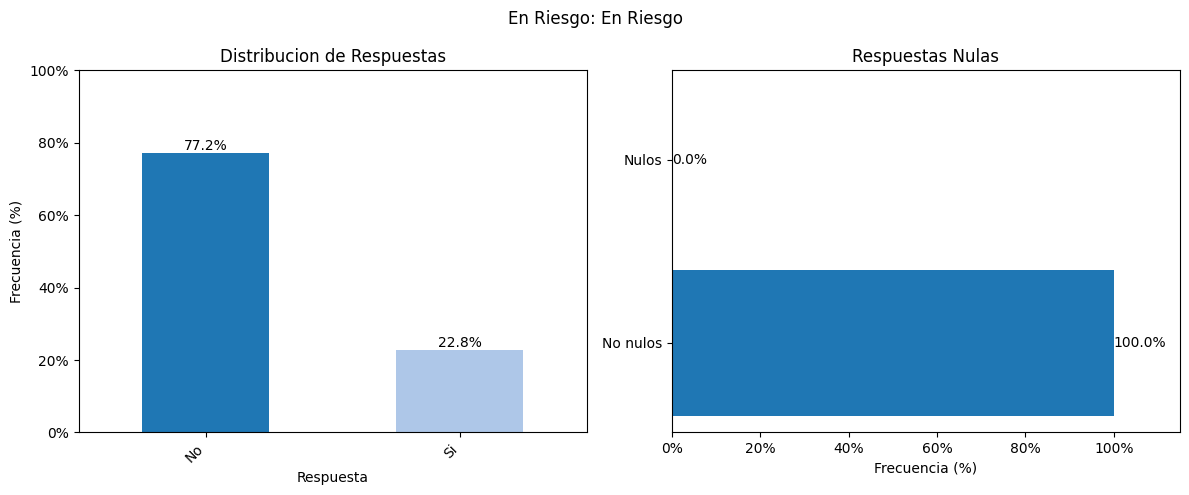

In [10]:
target = "En Riesgo"
df[target] = np.where((df["q25"] == 1) | (df["q26"] >= 2), 1, 0)
df["texto_" + target] = np.where(df[target] == 1, "Si", "No")

print_question(target)

### 4.2 Variables Demograficas

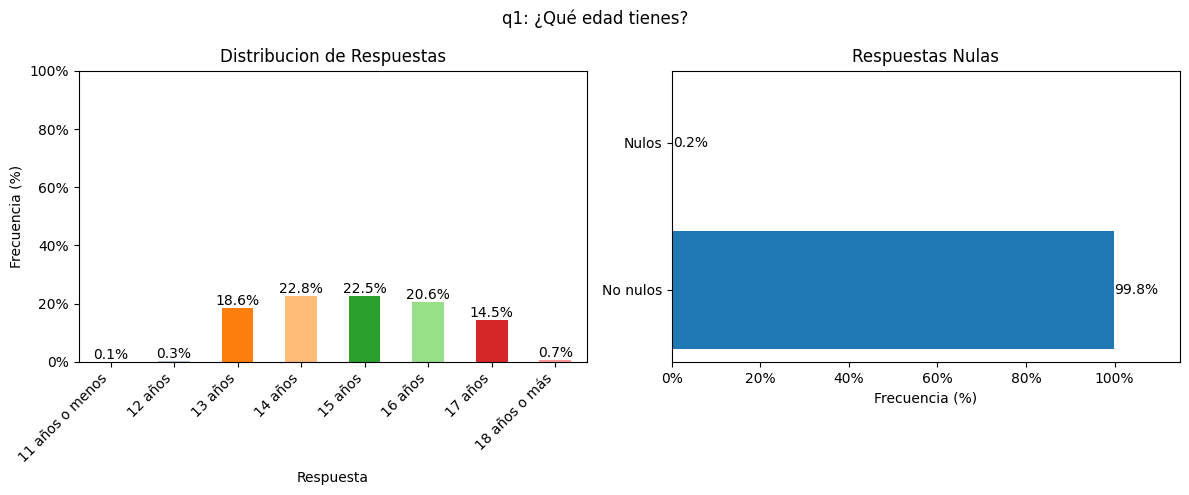

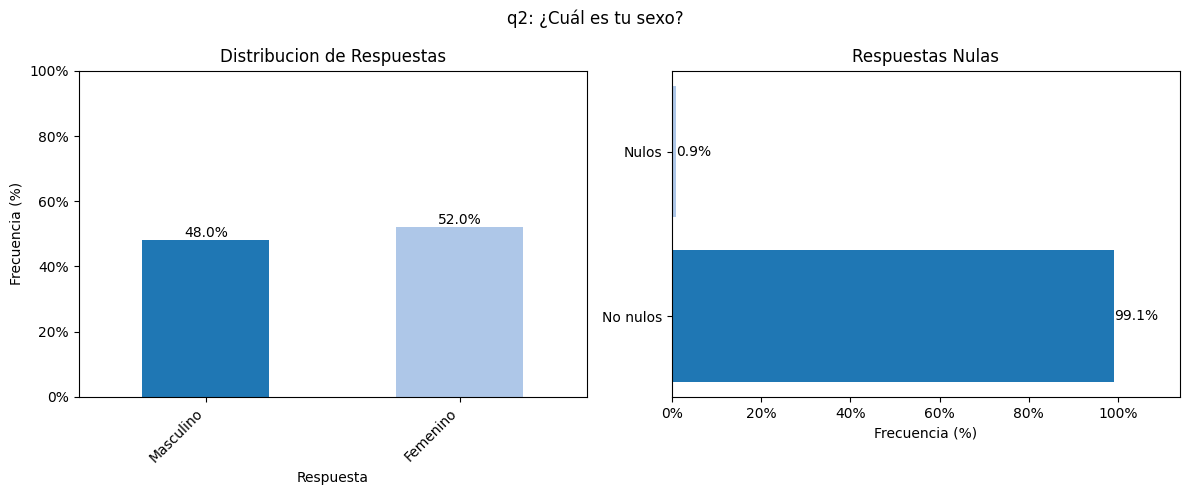

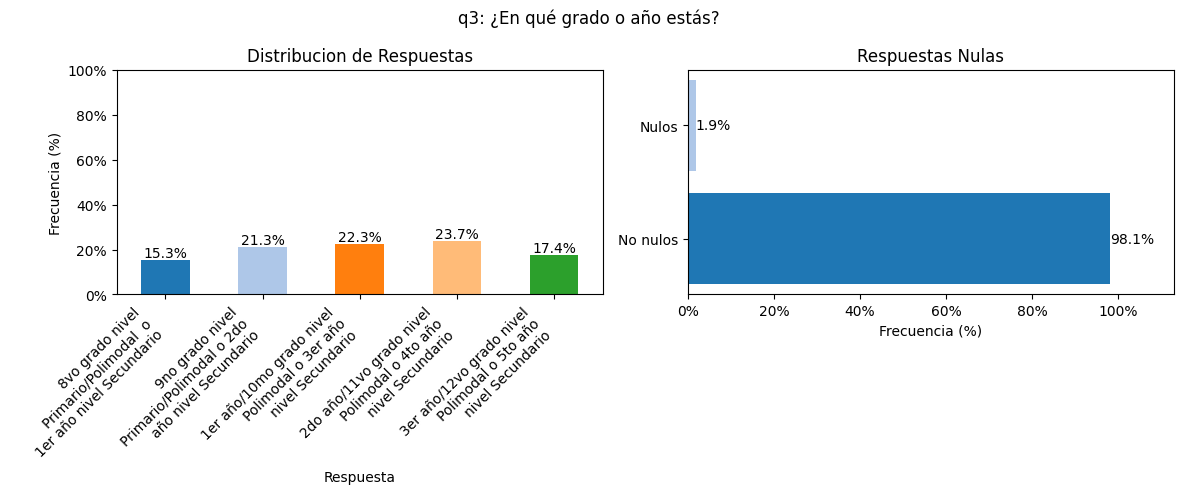

In [11]:
demograficas = ["q1", "q2", "q3"]

for q in demograficas:
    print_question(q)

### 4.3 Variables de Salud Mental

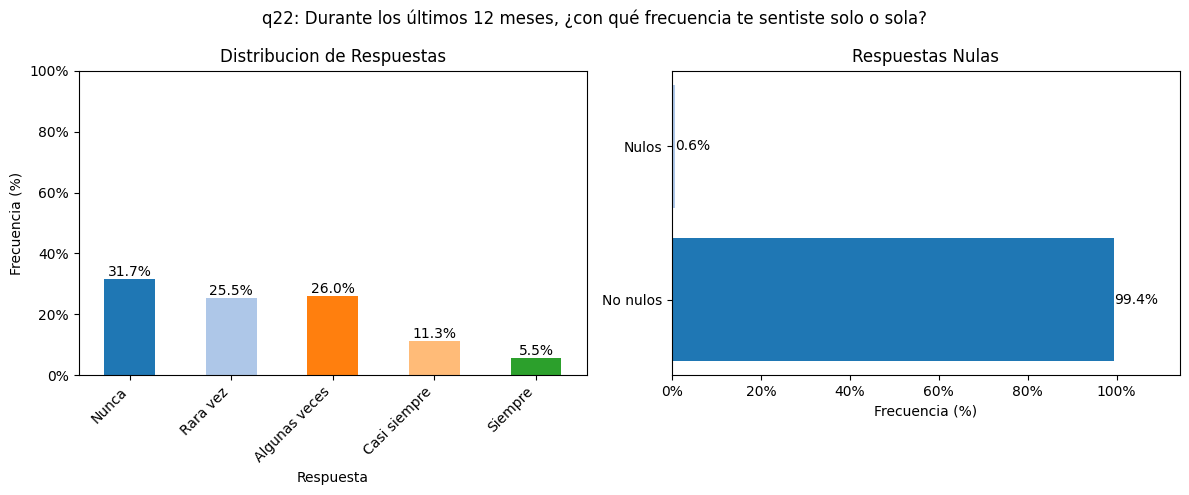

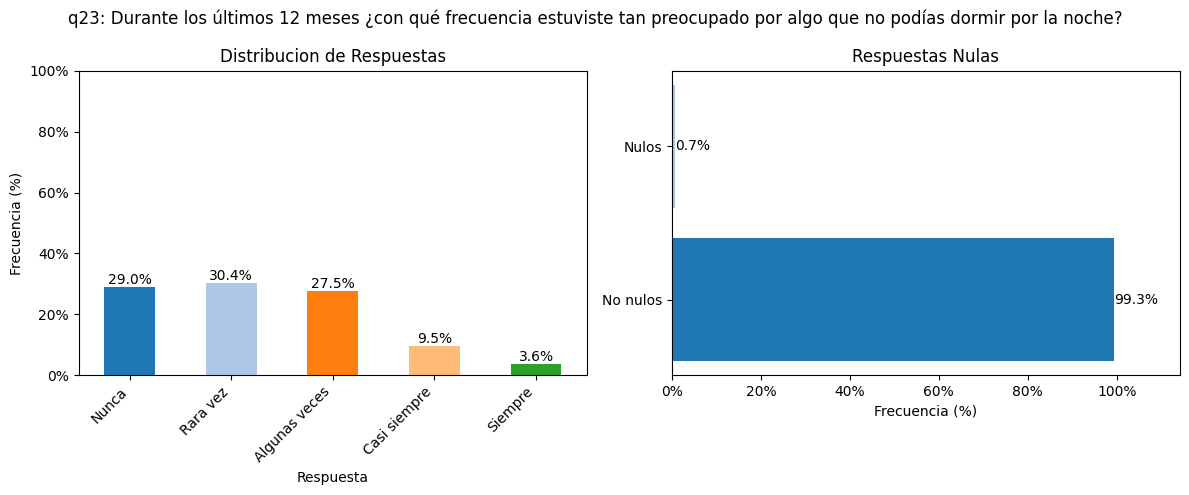

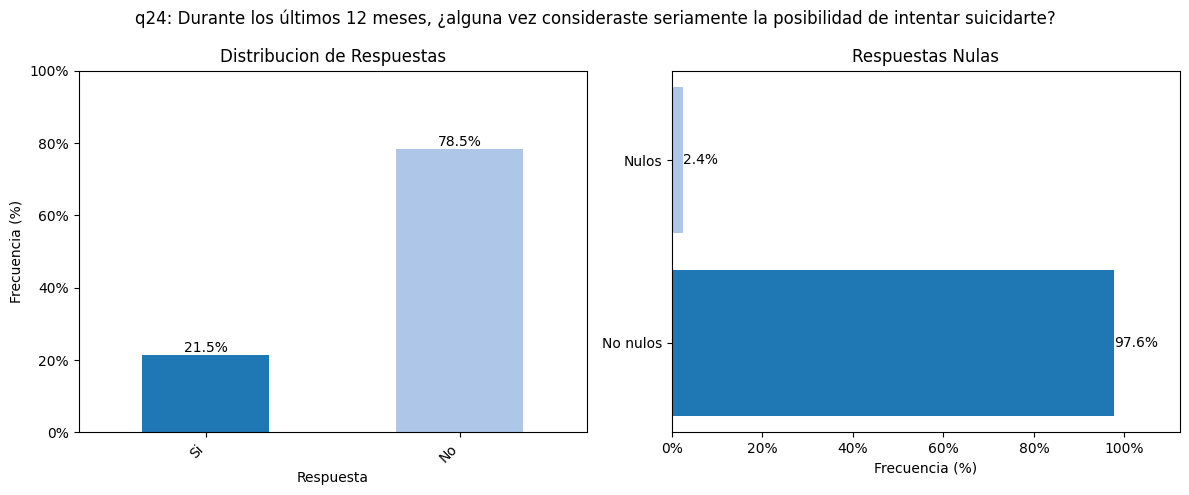

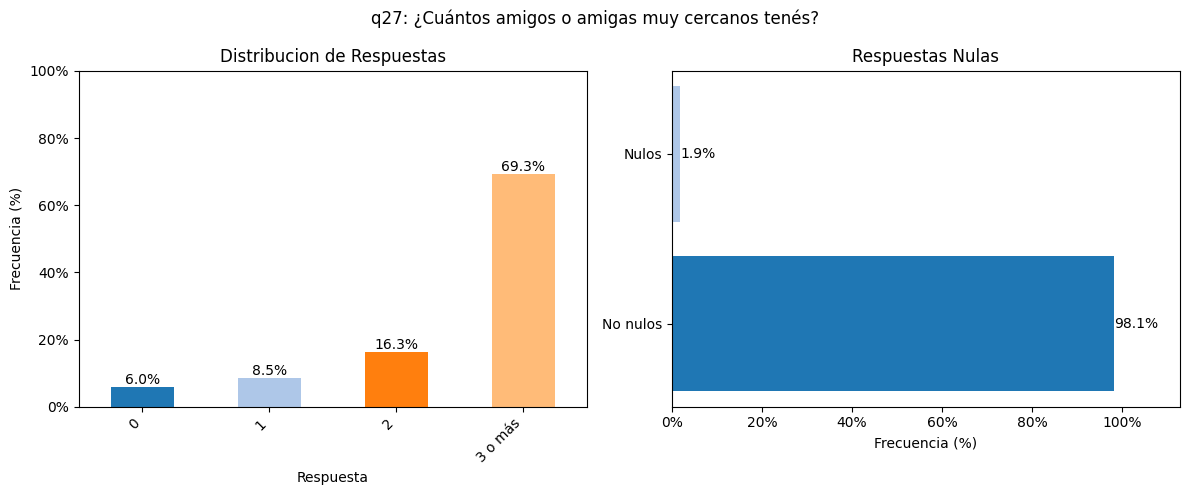

In [12]:
salud_mental = ["q22", "q23", "q24", "q27"]

for q in salud_mental:
    print_question(q)

### 4.4 Violencia y Bullying

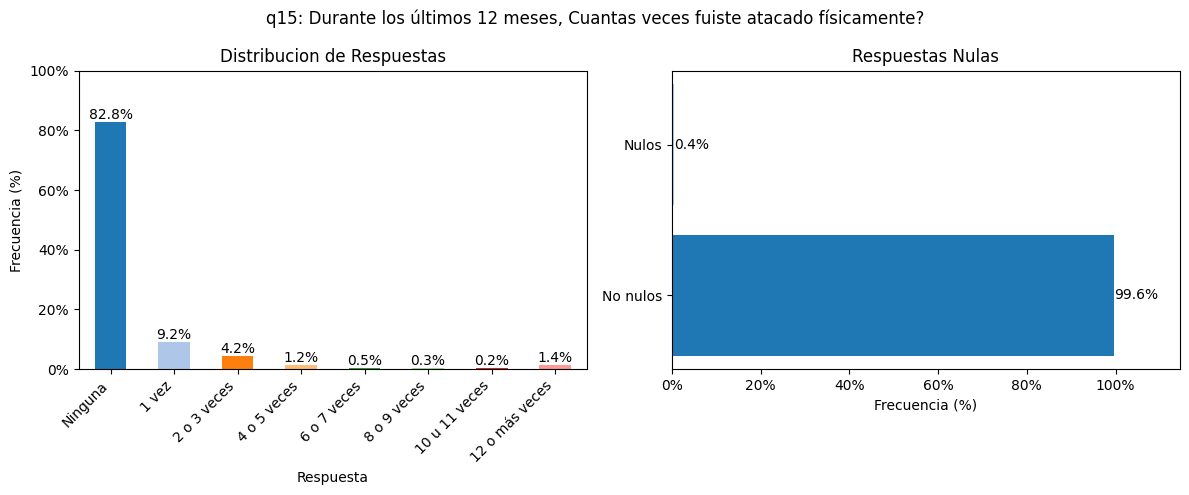

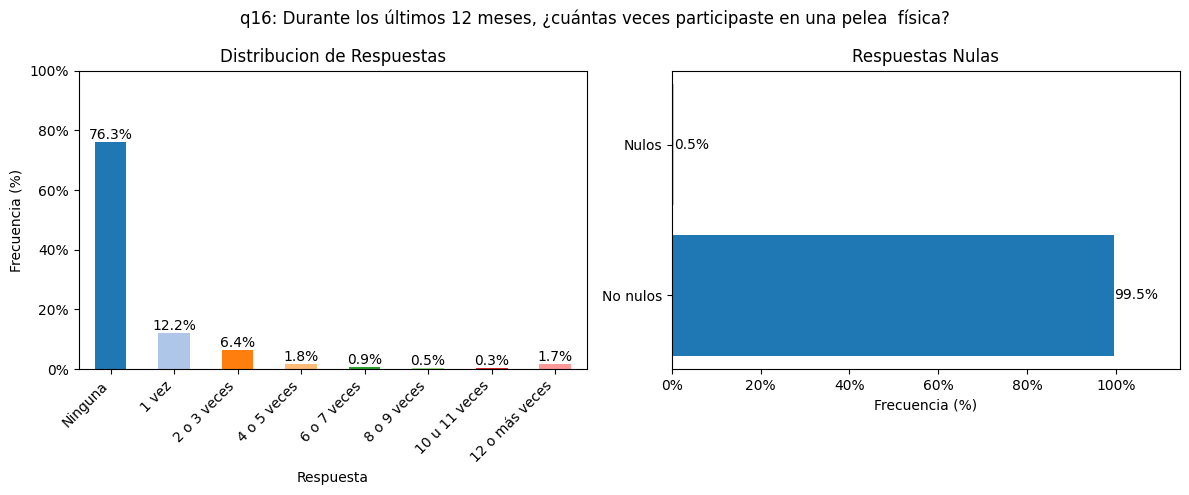

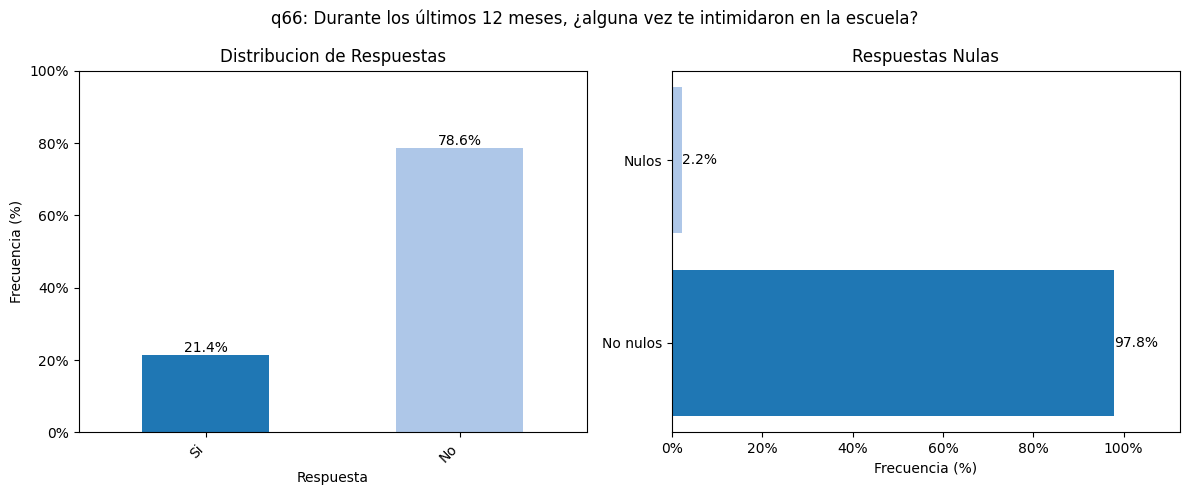

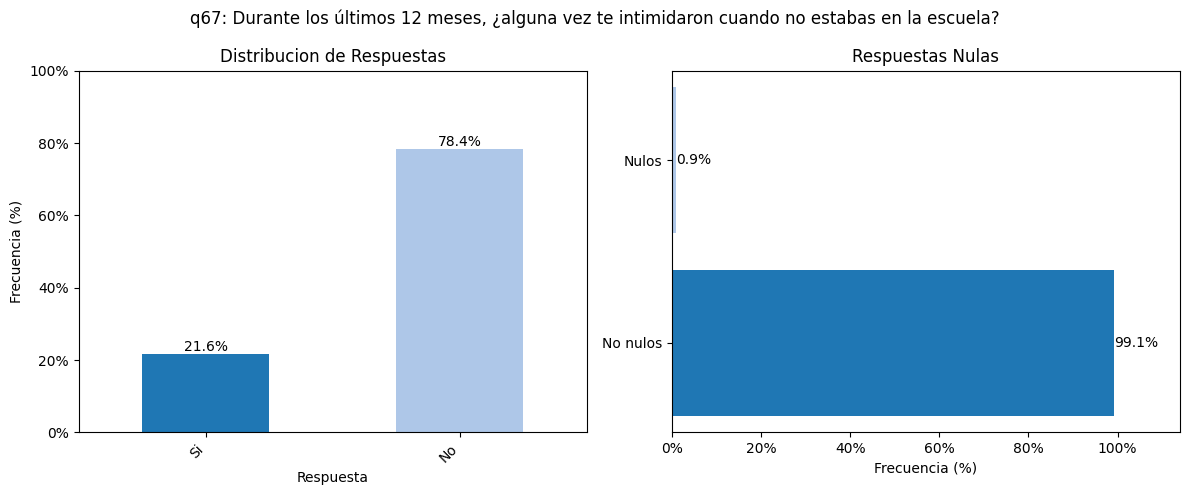

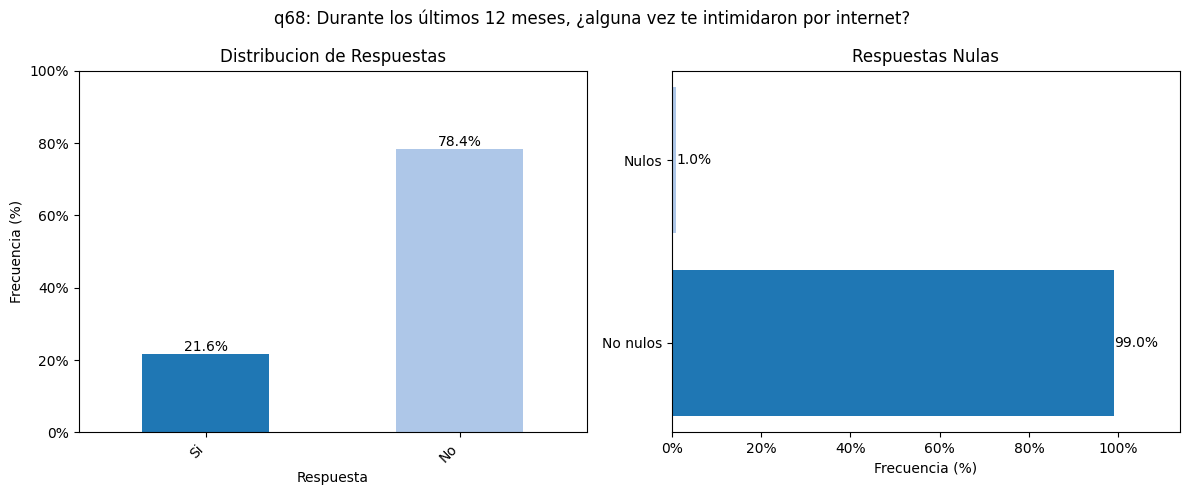

In [13]:
violencia = ["q15", "q16", "q66", "q67", "q68"]

for q in violencia:
    print_question(q)

### 4.5 Apoyo Familiar

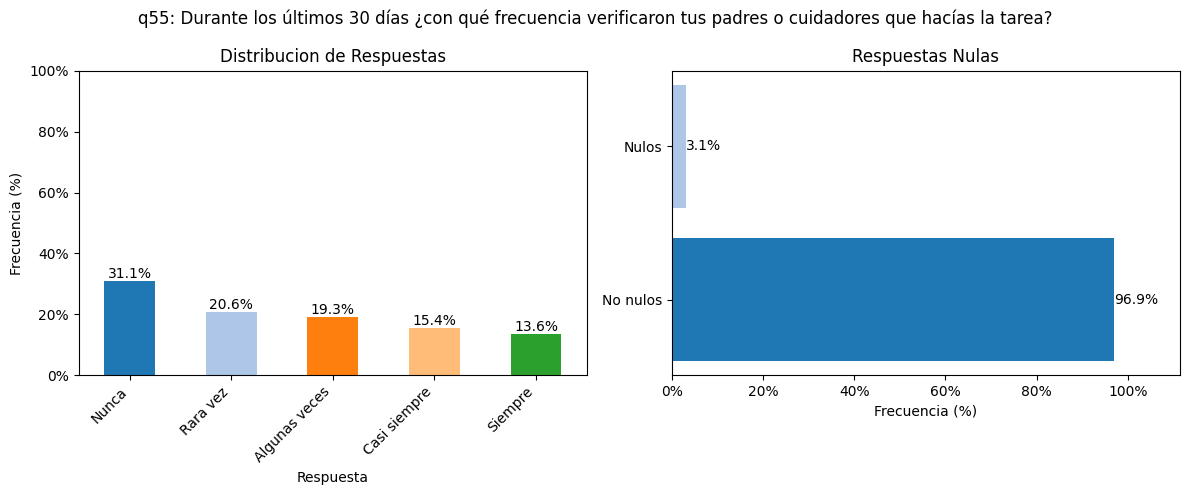

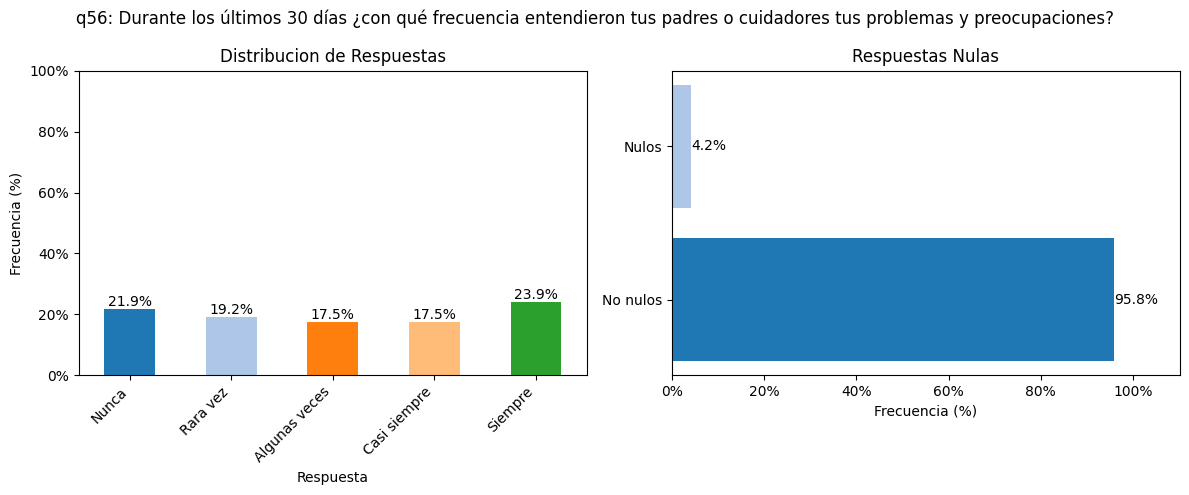

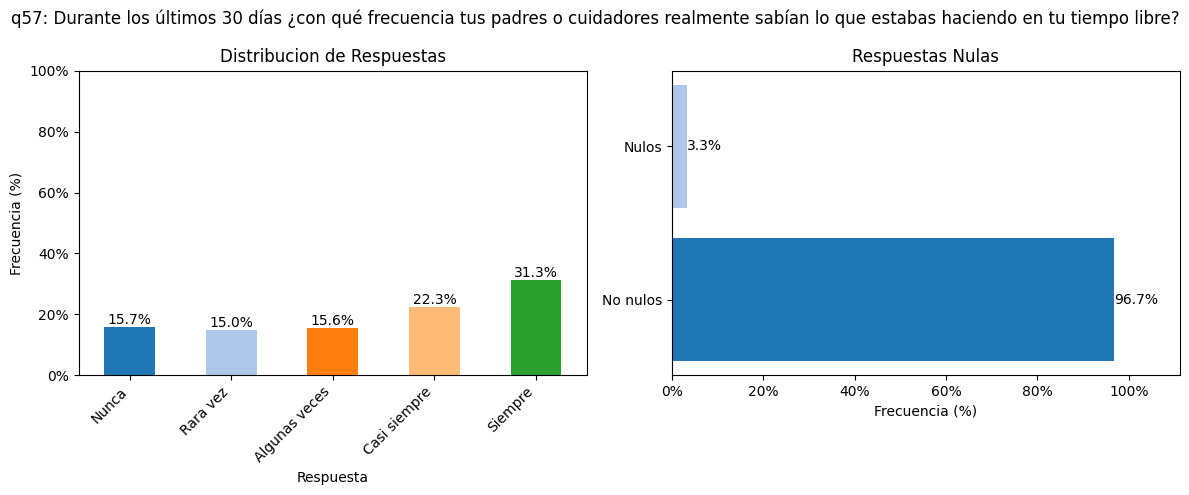

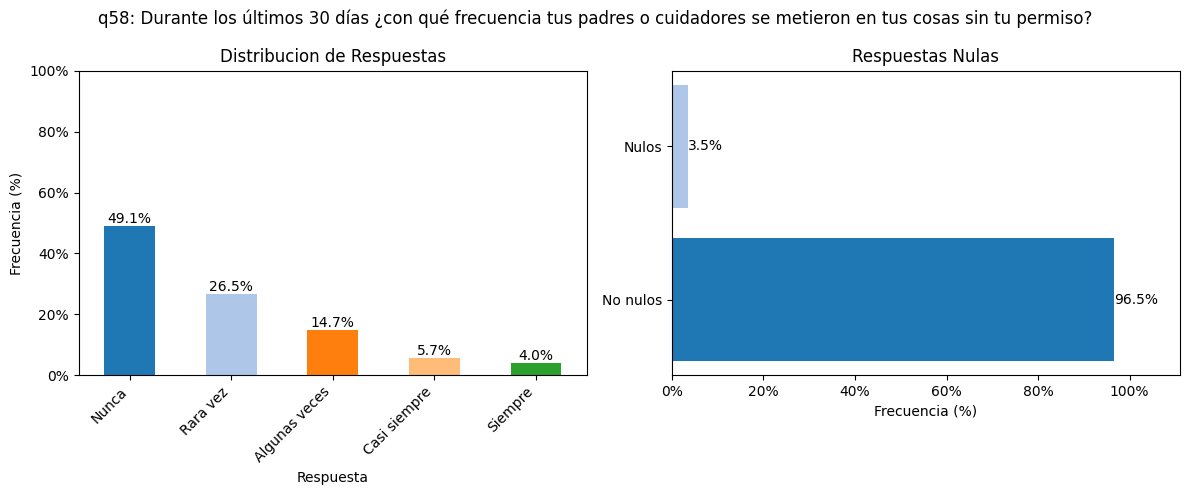

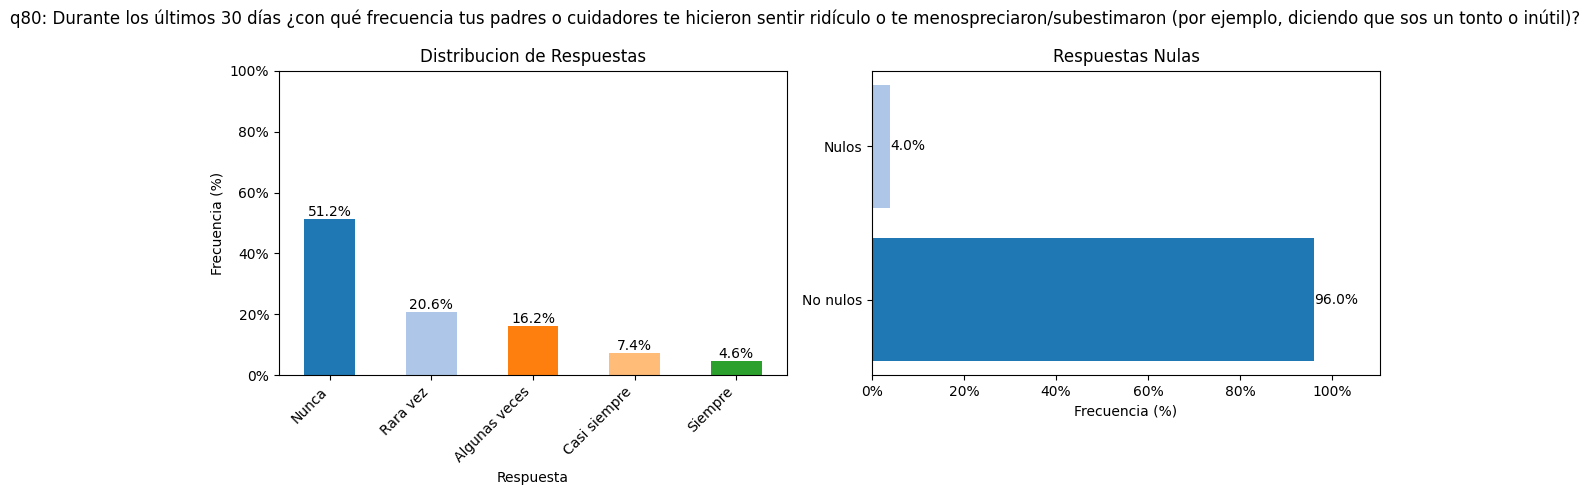

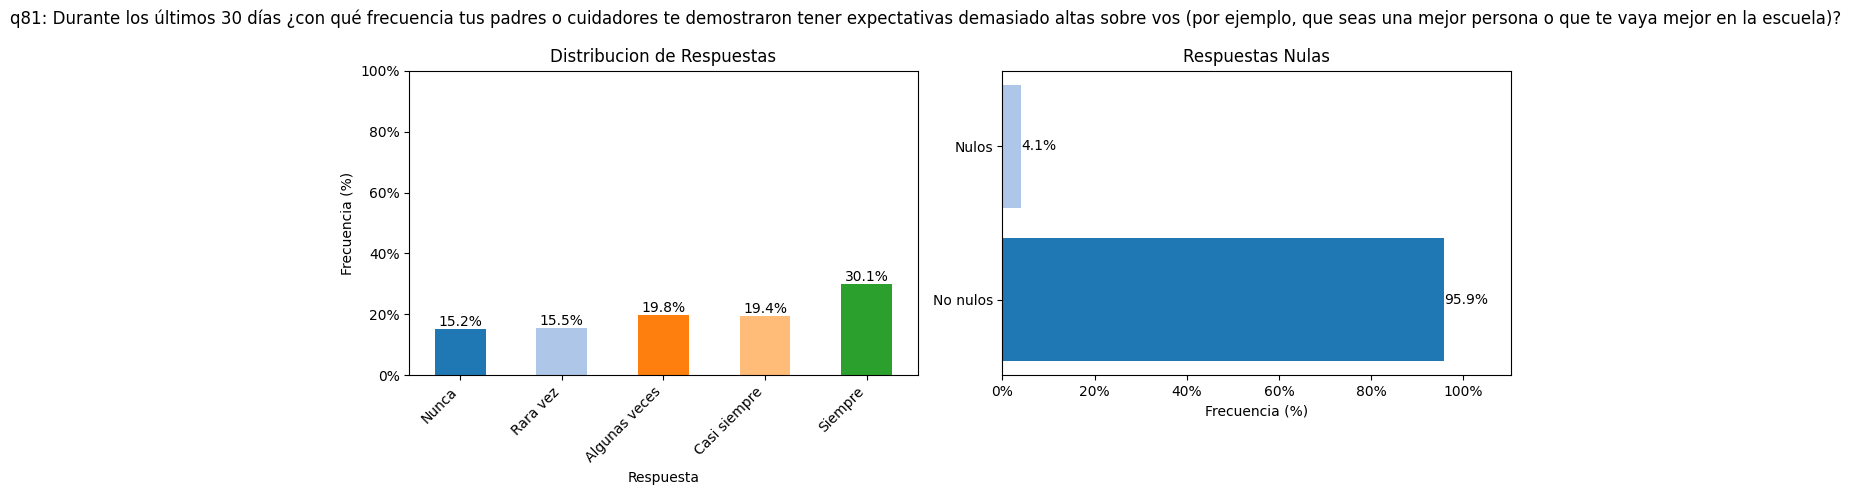

In [14]:
apoyo = ["q55", "q56", "q57", "q58", "q80", "q81"]

for q in apoyo:
    print_question(q)

### 4.6 Consumo de Sustancias

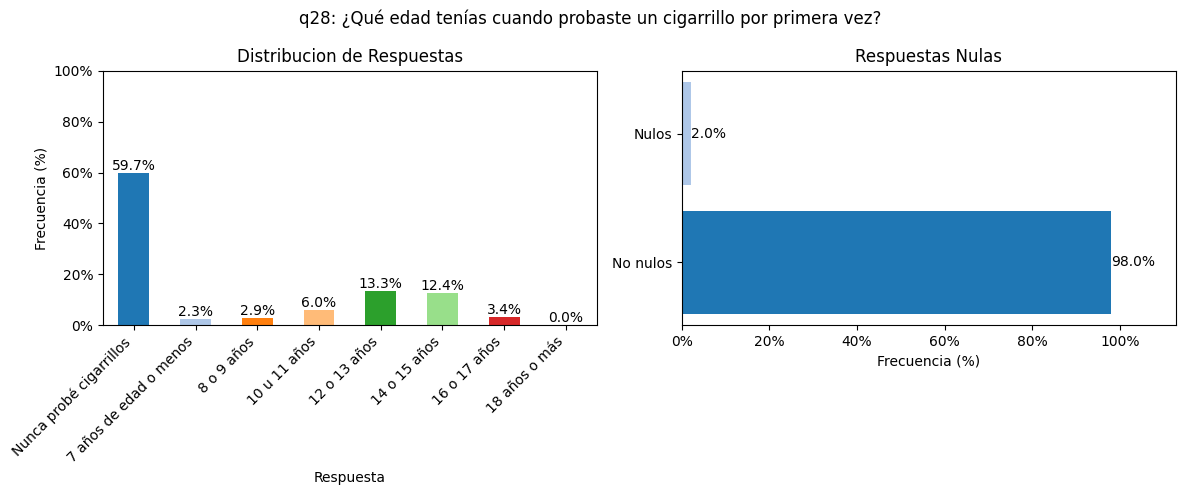

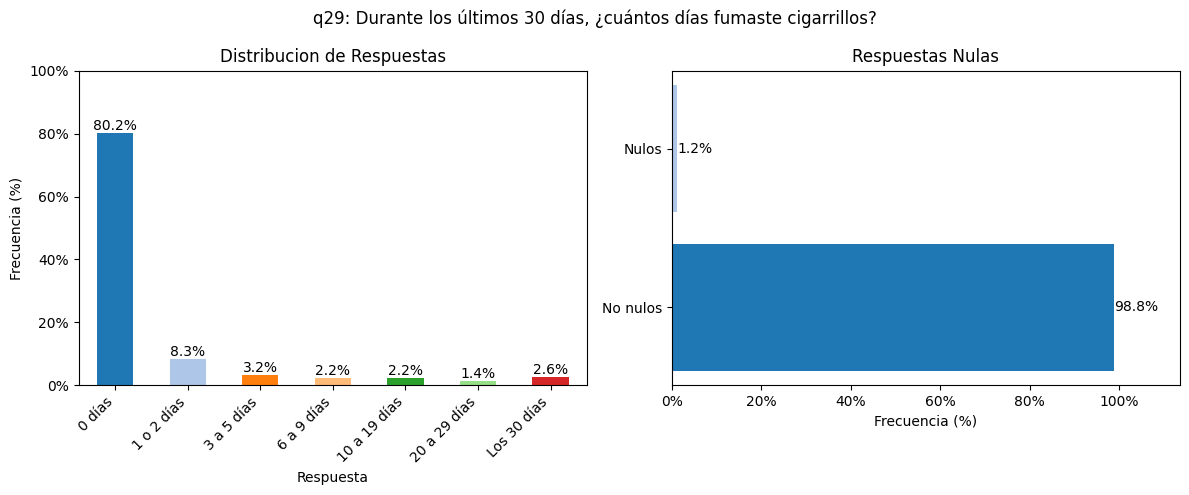

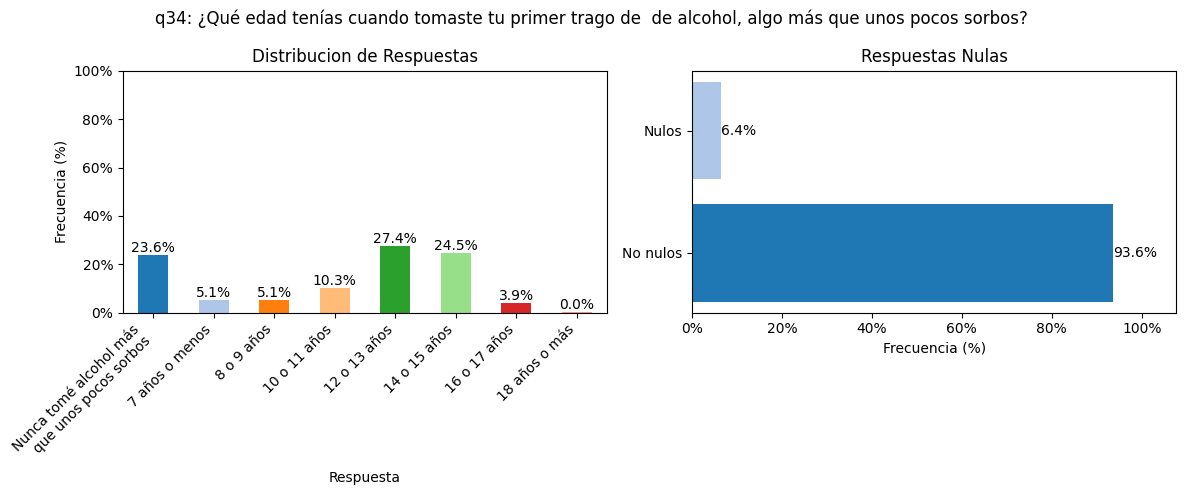

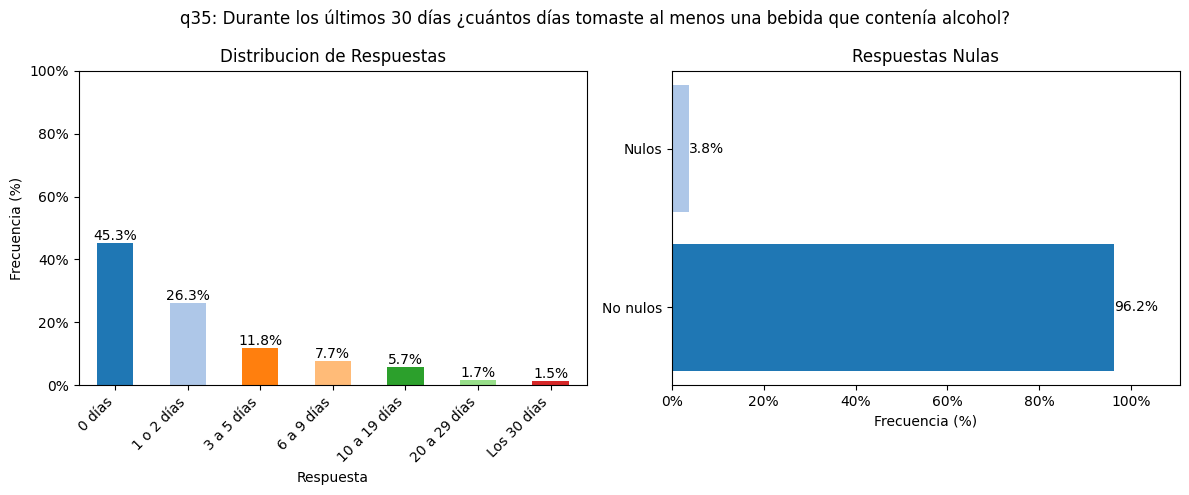

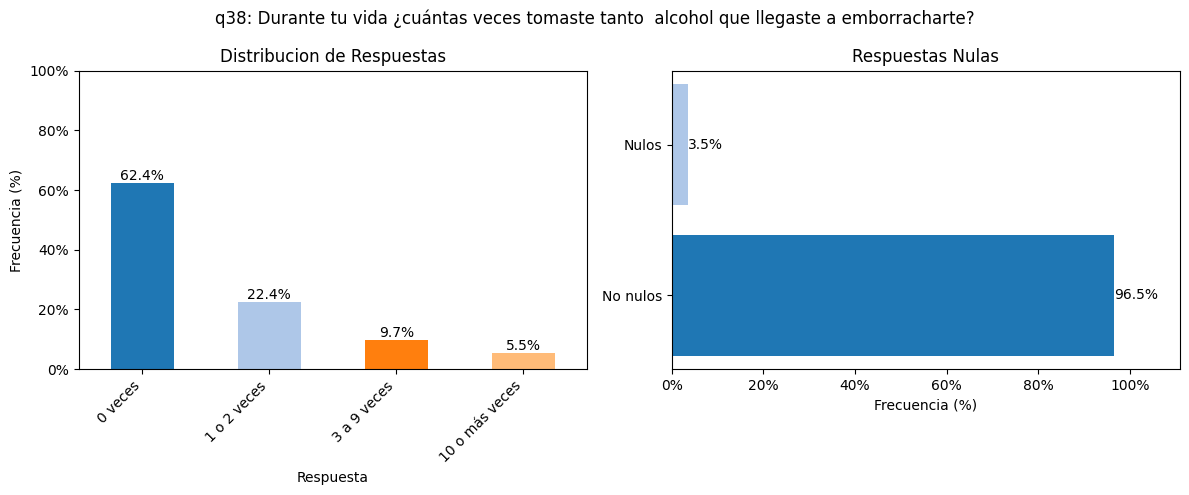

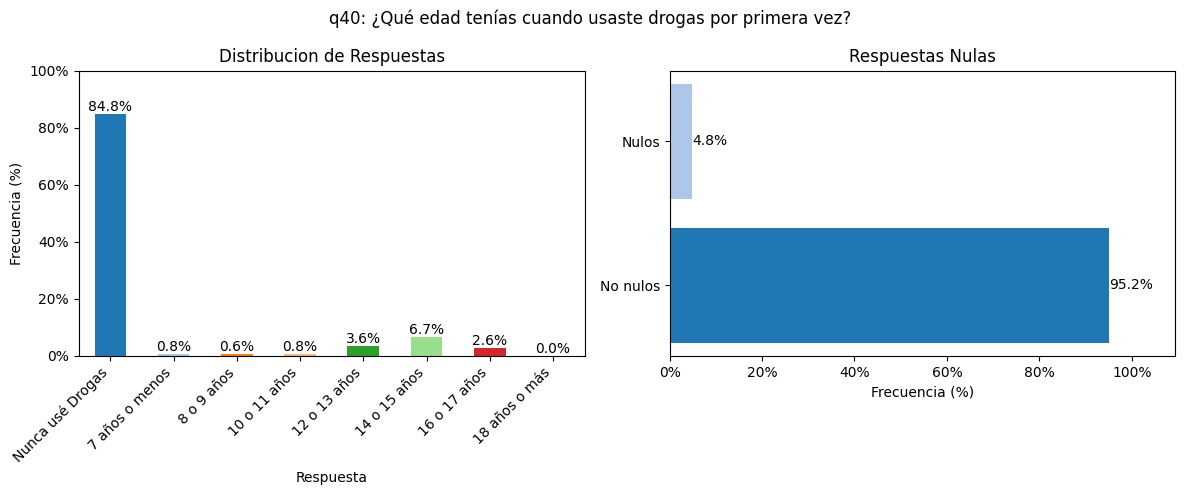

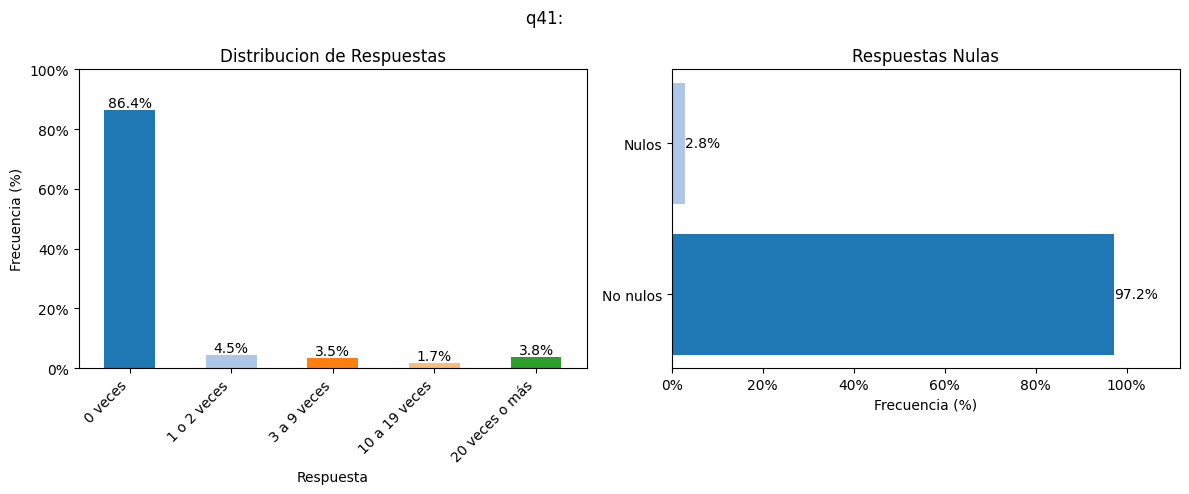

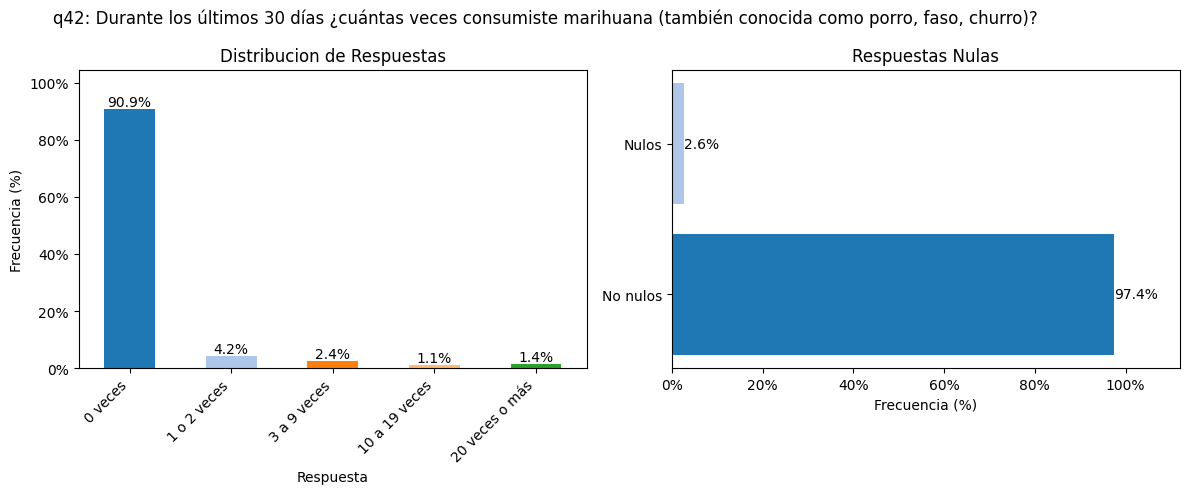

In [15]:
sustancias = ["q28", "q29", "q34", "q35", "q38", "q40", "q41", "q42"]

for q in sustancias:
    print_question(q)

### 4.7 Factores Sociales y Escolares

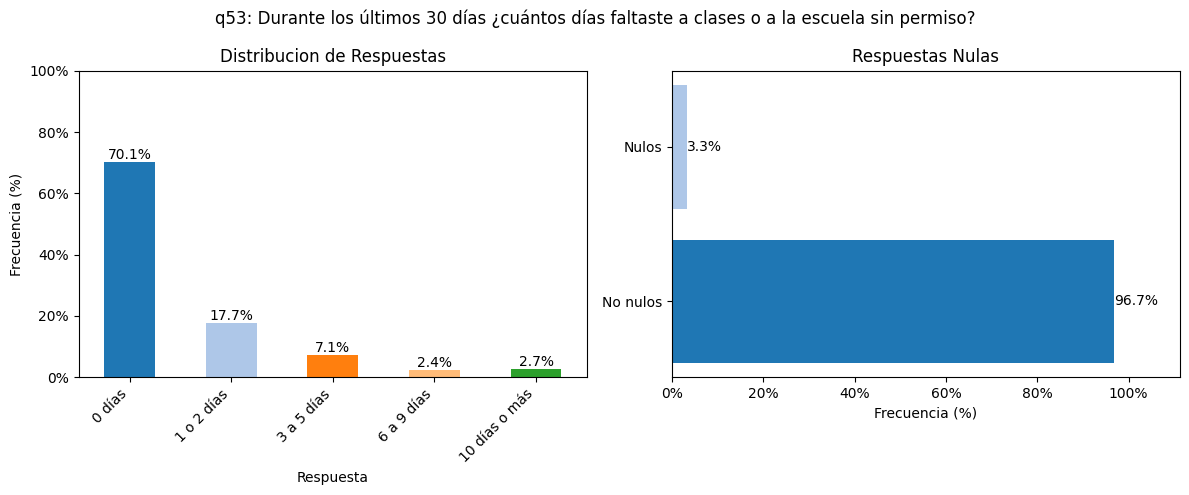

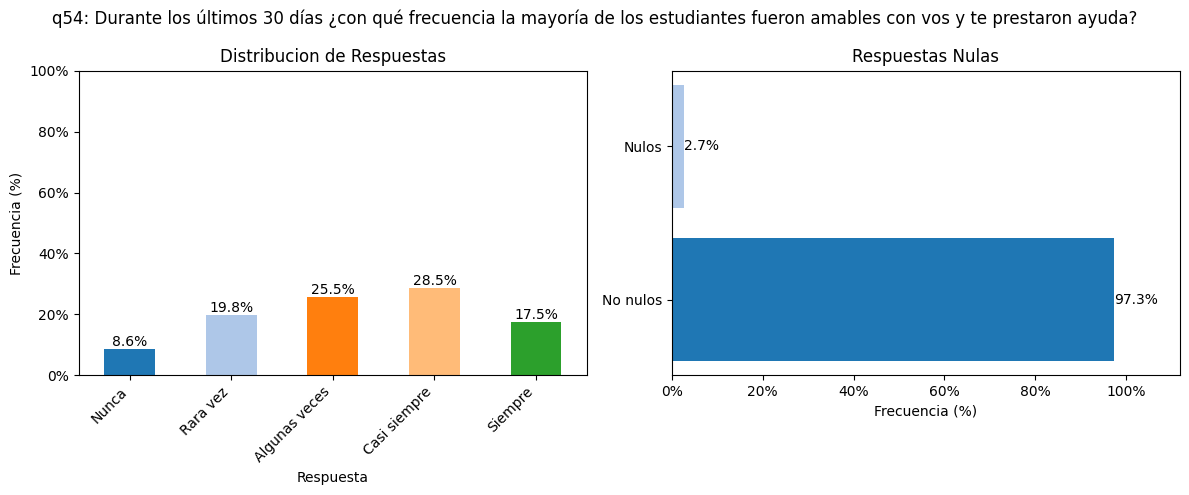

In [16]:
sociales = ["q53", "q54"]

for q in sociales:
    print_question(q)

### 4.8 Factores Socioeconomicos

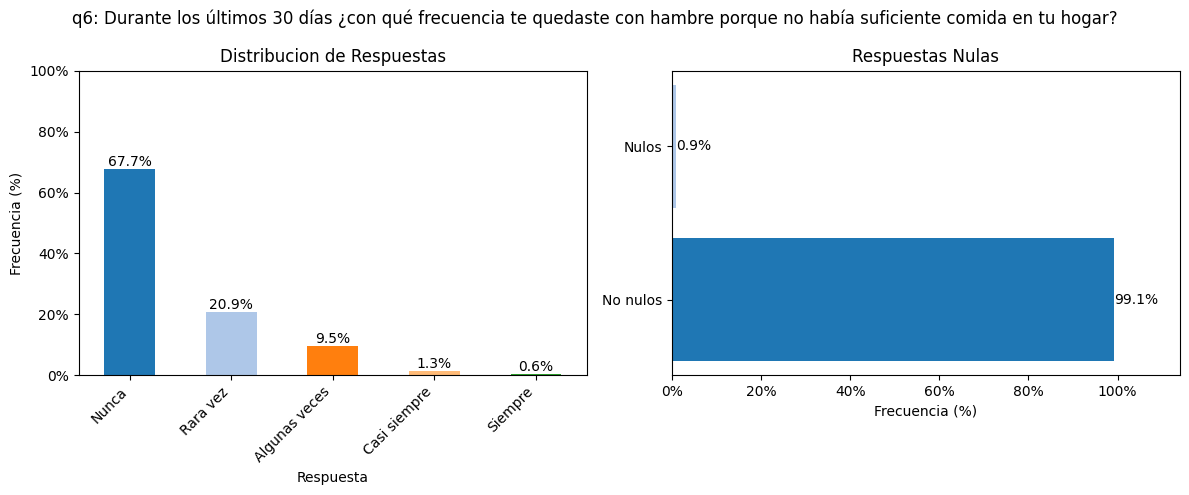

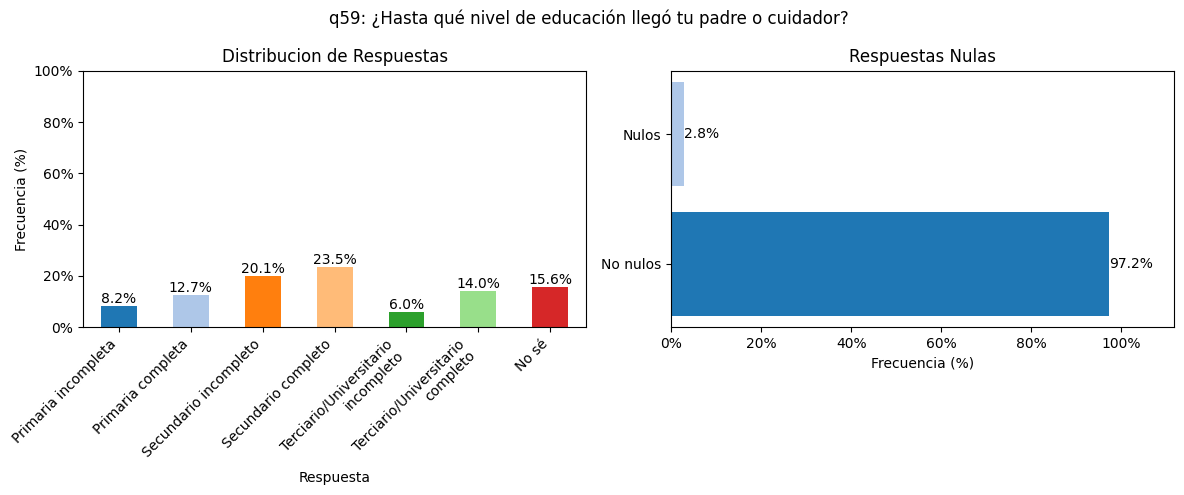

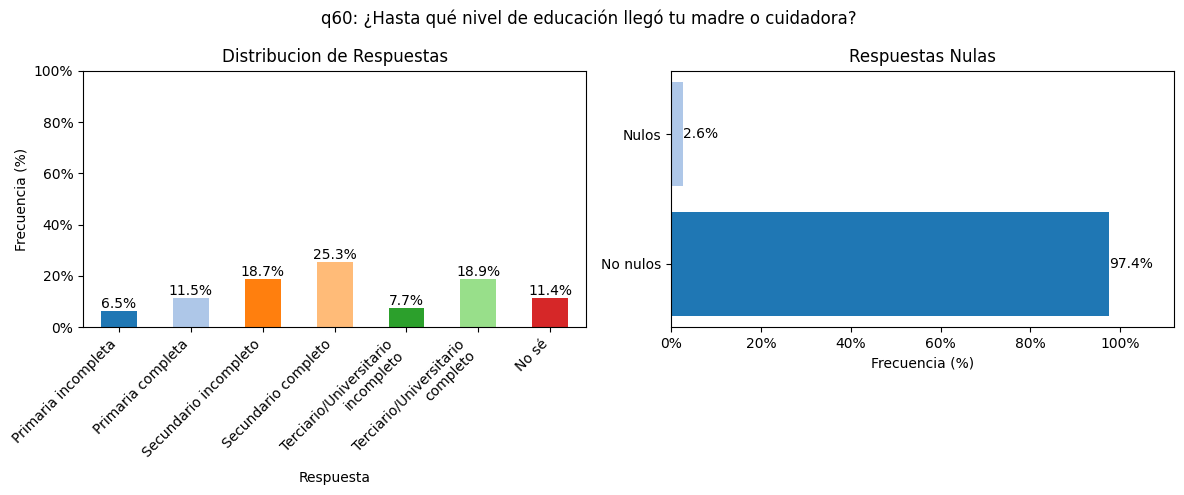

In [17]:
socioeconomicas = ["q6", "q59", "q60"]

for q in socioeconomicas:
    print_question(q)

## 5. Preprocesamiento

Las features que preseleccionamos para nuestro modelo entonces, seran:

In [21]:
features = sum([demograficas, [q for q in salud_mental if q not in ["q25", "q26"]], violencia, apoyo, sustancias, sociales, socioeconomicas, [target]], []) # Usamos sum() para aplanar la lista de listas
print(features)
print(len(features), "features")

['q1', 'q2', 'q3', 'q22', 'q23', 'q24', 'q27', 'q15', 'q16', 'q66', 'q67', 'q68', 'q55', 'q56', 'q57', 'q58', 'q80', 'q81', 'q28', 'q29', 'q34', 'q35', 'q38', 'q40', 'q41', 'q42', 'q53', 'q54', 'q6', 'q59', 'q60', 'En Riesgo']
32 features


In [22]:
data = df[[q for q in features]].copy()
data.head()

,q1,q2,q3,q22,q23,q24,q27,q15,q16,q66,...,q38,q40,q41,q42,q53,q54,q6,q59,q60,En Riesgo
0,3.0,2.0,2.0,5.0,5.0,1.0,3.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,5.0,1.0,2.0,6.0,2.0,0
1,3.0,2.0,2.0,1.0,1.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
2,4.0,1.0,4.0,1.0,2.0,NaN,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,3.0,1.0,4.0,4.0,0
3,6.0,1.0,2.0,1.0,3.0,2.0,4.0,1.0,3.0,2.0,...,2.0,1.0,1.0,1.0,1.0,3.0,1.0,3.0,3.0,0
4,3.0,2.0,2.0,2.0,3.0,2.0,4.0,1.0,1.0,2.0,...,1.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,1.0,0


In [23]:
data.shape

(56981, 32)